#**Deteksi Berita Hoax**
---

Link Kaggle: https://www.kaggle.com/datasets/mochamadabdulazis/deteksi-berita-hoaks-indo-dataset/data



##**Import Library**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import re
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import joblib

torch.manual_seed(42)
np.random.seed(42)

##**Data Load**

In [ ]:
turnbackhoax_ = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTJ8VBXqPTUqGbKq9620wbrNRNKcoFtyr7-Xca3yIUoFRnwQy1XWP5OspbIr_bpTqtrv2MeLSXQVJgL/pub?output=csv'
antaranews_ = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQUDXgAwpwlmUT-icGsM4x_O5HRoS1l6MlHrhUKNJe5QaK7v5eMhUBBYYg8P8x6WRDO3n1_KhKy6MwH/pub?output=csv'
detik_ = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQhtoEtEf4yAa0oLV7pBFbHtqvZ3xLF5alhGDKQRpLuFInmxn9ZbRxN5sNymobnIYvYFRN7yrtdz9-8/pub?output=csv'
kompas_ = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQbYeZVqaCZoQ5mgbbiEIOHjWvhLwvcNCbqdB0We1AoiZYr1rY-Wusq58fPGiOW8muYFuNKzU8hMD4o/pub?output=csv'

tb = pd.read_csv(turnbackhoax_)
cnn = pd.read_csv(antaranews_)
detik = pd.read_csv(detik_)
kompas = pd.read_csv(kompas_)

In [ ]:
datasets = [("TBH", tb), ("Antara", cnn), ("Detik", detik), ("Kompas", kompas)]

for name, df in datasets:
    print(f"Kolom di dataset {name}:")
    print(list(df.columns))
    print("-" * 60)

Kolom di dataset TBH:
['url', 'judul', 'narasi', 'hoax', 'clean_text']
------------------------------------------------------------
Kolom di dataset Antara:
['url', 'judul', 'narasi', 'label', 'clean_text']
------------------------------------------------------------
Kolom di dataset Detik:
['url', 'judul', 'narasi', 'label', 'clean_text']
------------------------------------------------------------
Kolom di dataset Kompas:
['url', 'judul', 'narasi', 'label', 'clean_text']
------------------------------------------------------------


In [ ]:
tb.shape

(12744, 5)

In [ ]:
cnn.shape

(4200, 5)

In [ ]:
detik.shape

(3500, 5)

In [ ]:
kompas.shape

(3500, 5)

##**Data Cleaning**
```
- ngerapihin nama kolom,
- buang baris judul yang jelas “bukan hoaks”,
- gabung judul + narasi,
- buang tag seperti [HOAX], [SALAH],
- buang URL, simbol, angka,
- apihin spasi,
- buang teks kosong.


In [ ]:
def clean_columns(df):
    df.columns = (
        df.columns
          .str.replace('\n', ' ', regex=False)
          .str.replace('\r', ' ', regex=False)
          .str.replace(r'\s+', ' ', regex=True)
          .str.strip()
    )
    return df

NON_HOAX_TAGS = ['berita', 'fakta', 'klarifikasi', 'benar', 'cek fakta']

def contains_non_hoax_tag(text):
    if pd.isna(text):
        return False
    text = str(text)
    match = re.match(r'[\[\(]\s*([^\]\)]+?)\s*[\]\)]\s*', text, flags=re.IGNORECASE)
    if match:
        tag = match.group(1).strip().lower()
        return tag in NON_HOAX_TAGS
    return False

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'\[[^\]]+\]', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_dataframe(df):
    df = clean_columns(df)

    if 'judul-1' in df.columns:
        judul_col = 'judul-1'
    elif 'judul' in df.columns:
        judul_col = 'judul'
    else:
        raise ValueError("Kolom judul tidak ditemukan (judul / judul-1).")

    narasi_col = 'narasi'

    df = df[~df[judul_col].apply(contains_non_hoax_tag)].copy()
    df[judul_col] = df[judul_col].fillna(df[narasi_col])
    df['text_raw'] = df[judul_col].fillna('') + ' ' + df[narasi_col].fillna('') #judul + narasi (digabung), belum dibersihkan.
    df['text'] = df['text_raw'].apply(clean_text)
    df = df[df['text'].str.strip() != ""]
    return df

In [ ]:
tb["label"] = 1
cnn["label"] = 0
detik["label"] = 0
kompas["label"] = 0

In [ ]:
tb     = preprocess_dataframe(tb)
cnn    = preprocess_dataframe(cnn)
detik  = preprocess_dataframe(detik)
kompas = preprocess_dataframe(kompas)

In [ ]:
df_kombinasi = pd.concat([tb, cnn, detik, kompas], ignore_index=True)
df_model = df_kombinasi[["text", "label"]].copy()

In [ ]:
df_kombinasi.shape

(22762, 8)

###**Checking Missing values**

In [ ]:
print(f'Data df_kombinasi\nTotal missing values: {df_kombinasi.isnull().sum().sum()}')

Data df_kombinasi
Total missing values: 11200


In [ ]:
print(f'Data CNN\nTotal missing values: {cnn.isnull().sum().sum()}')
print(f'\nData detik\nTotal missing values: {detik.isnull().sum().sum()}')
print(f'\nData kompas\nTotal missing values: {kompas.isnull().sum().sum()}')
print(f'\nData tb\nTotal missing values: {tb.isnull().sum().sum()}')

Data CNN
Total missing values: 0

Data detik
Total missing values: 0

Data kompas
Total missing values: 0

Data tb
Total missing values: 0


###**Checking rows duplicated**

In [ ]:
df_kombinasi = df_kombinasi.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
print(f'baris duplikat: {df_kombinasi.duplicated().sum()}')

baris duplikat: 0


In [ ]:
print(f'Data CNN\nbaris duplikat: {cnn.duplicated().sum()}')
print(f'\nData detik\nbaris duplikat: {detik.duplicated().sum()}')
print(f'\nData kompas\nbaris duplikat: {kompas.duplicated().sum()}')
print(f'\nData tb\nbaris duplikat: {tb.duplicated().sum()}')

Data CNN
baris duplikat: 0

Data detik
baris duplikat: 0

Data kompas
baris duplikat: 0

Data tb
baris duplikat: 0


In [ ]:
tb.shape

(11562, 8)

In [ ]:
cnn.shape

(4200, 7)

In [ ]:
detik.shape

(3500, 7)

In [ ]:
kompas.shape

(3500, 7)

In [ ]:
df_kombinasi.shape

(20773, 8)

##**Data Preview**

In [ ]:
print("Data CNN:")
display(cnn.head())

print("\n\nData DETIK:")
display(detik.head())

print("\n\nData KOMPAS:")
display(kompas.head())

print("\n\nData TBH:")
display(tb.head())

Data CNN:


,url,judul,narasi,label,clean_text,text_raw,text
0,https://www.antaranews.com/berita/5272973/angg...,Anggota DPR minta polisi ungkap dalang perusak...,Jakarta (ANTARA) - Anggota Komisi IV DPR RI Ra...,0,anggota komisi iv dpr ri rajiv meminta aparat ...,Anggota DPR minta polisi ungkap dalang perusak...,anggota dpr minta polisi ungkap dalang perusak...
1,https://www.antaranews.com/berita/5271789/bskd...,BSKDN: Kepentingan umum harus jadi orientasi u...,Jakarta (ANTARA) - Badan Strategi Kebijakan Da...,0,badan strategi kebijakan dalam negeri (bskdn) ...,BSKDN: Kepentingan umum harus jadi orientasi u...,bskdn kepentingan umum harus jadi orientasi ut...
2,https://www.antaranews.com/berita/5271561/sesk...,Seskab: Prabowo minta respons cepat dan bantua...,Jakarta (ANTARA) - Sekretaris Kabinet (Seskab)...,0,sekretaris kabinet (seskab) teddy indra wijaya...,Seskab: Prabowo minta respons cepat dan bantua...,seskab prabowo minta respons cepat dan bantuan...
3,https://www.antaranews.com/berita/5271817/ekon...,Ekonom Golkar nilai kebijakan PLTS satu desa s...,Jakarta (ANTARA) - Ekonom Partai Golkar Abdul ...,0,ekonom partai golkar abdul rahman farisi meman...,Ekonom Golkar nilai kebijakan PLTS satu desa s...,ekonom golkar nilai kebijakan plts satu desa s...
4,https://www.antaranews.com/berita/5272929/wame...,Wamendagri: Bangun layanan publik sesuai kebut...,Jakarta (ANTARA) - Wakil Menteri Dalam Negeri ...,0,wakil menteri dalam negeri (wamendagri) bima a...,Wamendagri: Bangun layanan publik sesuai kebut...,wamendagri bangun layanan publik sesuai kebutu...




Data DETIK:


,url,judul,narasi,label,clean_text,text_raw,text
0,https://health.detik.com/fotohealth/d-8212146/...,Sekolah Lansia Ceria Bersama Hadirkan Kegiatan...,Aceh - Lansia di Aceh Besar mengikuti kegiatan...,0,lansia di aceh besar mengikuti kegiatan anyama...,Sekolah Lansia Ceria Bersama Hadirkan Kegiatan...,sekolah lansia ceria bersama hadirkan kegiatan...
1,https://health.detik.com/berita-detikhealth/d-...,Peneliti AS Semakin Dekat Wujudkan Transplanta...,Para dokter di NYU Langone Health melaporkan d...,0,para dokter di nyu langone health melaporkan d...,Peneliti AS Semakin Dekat Wujudkan Transplanta...,peneliti as semakin dekat wujudkan transplanta...
2,https://health.detik.com/kebugaran/d-8213096/l...,"Lari di Rute Hijau IPB Half Marathon 2025, Pul...",Ingin menjajal alternatif race lari dengan rut...,0,ingin menjajal alternatif race lari dengan rut...,"Lari di Rute Hijau IPB Half Marathon 2025, Pul...",lari di rute hijau ipb half marathon pulang pu...
3,https://health.detik.com/berita-detikhealth/d-...,Gen Z Makin Berisiko Kena Penyakit Gula gegara...,Diabetes melitus merupakan salah penyakit kron...,0,diabetes melitus merupakan salah penyakit kron...,Gen Z Makin Berisiko Kena Penyakit Gula gegara...,gen z makin berisiko kena penyakit gula gegara...
4,https://health.detik.com/berita-detikhealth/d-...,Mengenal Kondisi Syok Kardiogenik Jantung dan ...,Tidak semua serangan jantung langsung berakhir...,0,tidak semua serangan jantung langsung berakhir...,Mengenal Kondisi Syok Kardiogenik Jantung dan ...,mengenal kondisi syok kardiogenik jantung dan ...




Data KOMPAS:


,url,judul,narasi,label,clean_text,text_raw,text
0,https://tekno.kompas.com/read/2025/11/17/11150...,"Harga Bitcoin Sentuh Titik Terendah, Diprediks...",KOMPAS.com - Harga mata uang kripto (cyptocurr...,0,harga mata uang kripto (cyptocurrency) populer...,"Harga Bitcoin Sentuh Titik Terendah, Diprediks...",harga bitcoin sentuh titik terendah diprediksi...
1,https://tekno.kompas.com/read/2025/11/17/08010...,Video Receh dan Lucu di Sora Ternyata Bikin Ka...,KOMPAS.com - Pernah iseng membuat video lucu a...,0,pernah iseng membuat video lucu atau receh di ...,Video Receh dan Lucu di Sora Ternyata Bikin Ka...,video receh dan lucu di sora ternyata bikin ka...
2,https://tekno.kompas.com/read/2025/11/17/13350...,20 Prompt Gemini AI Foto Ulang Tahun untuk Pas...,KOMPAS.com - Momen ulang tahun pasangan atau k...,0,momen ulang tahun pasangan atau keluarga bisa ...,20 Prompt Gemini AI Foto Ulang Tahun untuk Pas...,prompt gemini ai foto ulang tahun untuk pasang...
3,https://tekno.kompas.com/read/2025/11/17/17350...,Trik Kunci Layar iPhone dengan Ketuk Logo Appl...,KOMPAS.com - iPhone dibekali berbagai fitur ya...,0,"iphone dibekali berbagai fitur yang menarik, s...",Trik Kunci Layar iPhone dengan Ketuk Logo Appl...,trik kunci layar iphone dengan ketuk logo appl...
4,https://tekno.kompas.com/read/2025/11/17/07000...,Peringatan Google: HP Android Jangan Sembarang...,KOMPAS.com - Google memperingatkan pengguna po...,0,google memperingatkan pengguna ponsel android ...,Peringatan Google: HP Android Jangan Sembarang...,peringatan google hp android jangan sembaranga...




Data TBH:


,url,judul,narasi,hoax,clean_text,label,text_raw,text
0,https://turnbackhoax.id/articles/30091,[SALAH] Menkeu Purbaya Curiga Permainan Bunga ...,FAKTOR PENCAIRAN TPG SERING TELAT Menkeu Purba...,1,faktor pencairan tpg sering telat menkeu purba...,1,[SALAH] Menkeu Purbaya Curiga Permainan Bunga ...,menkeu purbaya curiga permainan bunga rp trili...
1,https://turnbackhoax.id/articles/30090,[SALAH] Bahlil Sambut Kedatangan Ahli Gizi dar...,BREAKING NEWS Ahli gizi dari india resmi tiba ...,1,breaking news ahli gizi dari india resmi tiba ...,1,[SALAH] Bahlil Sambut Kedatangan Ahli Gizi dar...,bahlil sambut kedatangan ahli gizi dari india ...
2,https://turnbackhoax.id/articles/30089,[SALAH] Video Cak Imin Membicarakan tentang Pe...,Program pemutihan tunggakan BPJS Kesehatan aka...,1,program pemutihan tunggakan bpjs kesehatan aka...,1,[SALAH] Video Cak Imin Membicarakan tentang Pe...,video cak imin membicarakan tentang pemutihan ...
3,https://turnbackhoax.id/articles/30088,Cek Fakta: Tidak Benar Link Pendaftaran Progra...,Kabar baik untuk semua! tahun 2025 tunggakan B...,1,kabar baik untuk semua! tahun 2025 tunggakan b...,1,Cek Fakta: Tidak Benar Link Pendaftaran Progra...,cek fakta tidak benar link pendaftaran program...
4,https://turnbackhoax.id/articles/30087,Viral Aturan Tilang 2026 Denda Manual Naik 150...,Isu semakin panas! Pak Kapolri yang satu ini k...,1,isu semakin panas! pak kapolri yang satu ini k...,1,Viral Aturan Tilang 2026 Denda Manual Naik 150...,viral aturan tilang denda manual naik benarkah...


##**Exploratory Data Analysis**

###Distribusi label (Real vs Hoax)

Jumlah data per label:
label
0    11154
1     9619
Name: count, dtype: int64

Persentase data per label (%):
label
0    53.69
1    46.31
Name: proportion, dtype: float64


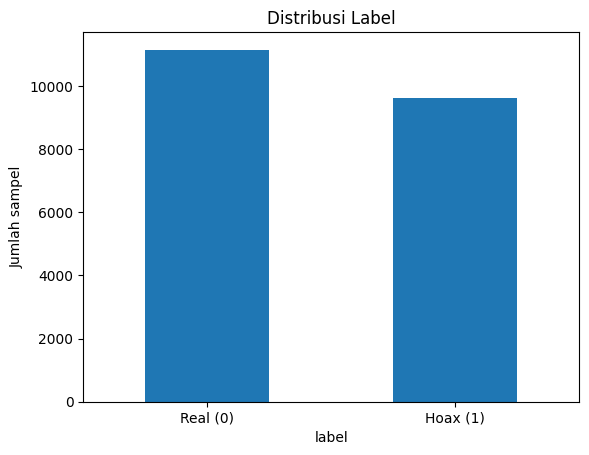

In [ ]:
label_counts = df_kombinasi["label"].value_counts().sort_index()
label_pct    = df_kombinasi["label"].value_counts(normalize=True).sort_index() * 100

print("Jumlah data per label:")
print(label_counts)

print("\nPersentase data per label (%):")
print(label_pct.round(2))

plt.figure()
label_counts.plot(kind="bar")
plt.xticks([0, 1], ["Real (0)", "Hoax (1)"], rotation=0)
plt.ylabel("Jumlah sampel")
plt.title("Distribusi Label")
plt.show()

###Distribusi per sumber

Jumlah data per sumber:
source
tbh       11562
antara     4200
detik      3500
kompas     3500
Name: count, dtype: int64

Persentase data per sumber (%):
source
tbh       50.80
antara    18.45
detik     15.38
kompas    15.38
Name: proportion, dtype: float64


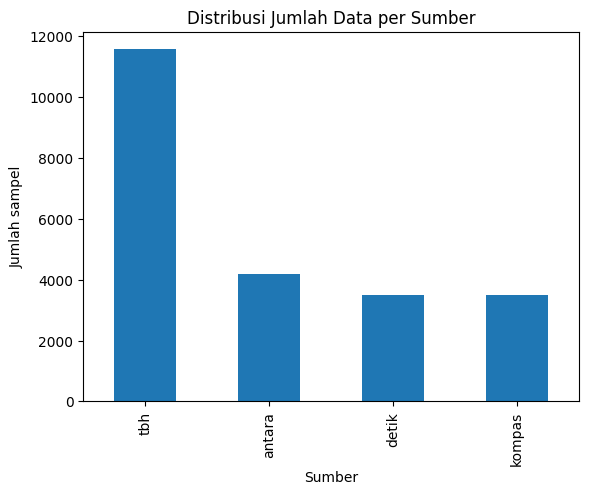

In [ ]:
tb["source"]     = "tbh"
cnn["source"]    = "antara"
detik["source"]  = "detik"
kompas["source"] = "kompas"

df_kombinasi = pd.concat([tb, cnn, detik, kompas], ignore_index=True)
df_kombinasi = df_kombinasi[["text", "label", "source"]].copy()

source_counts = df_kombinasi["source"].value_counts()
source_pct    = df_kombinasi["source"].value_counts(normalize=True) * 100

print("Jumlah data per sumber:")
print(source_counts)

print("\nPersentase data per sumber (%):")
print(source_pct.round(2))

plt.figure()
source_counts.plot(kind="bar")
plt.ylabel("Jumlah sampel")
plt.xlabel("Sumber")
plt.title("Distribusi Jumlah Data per Sumber")
plt.show()

###Panjang teks per label (Real vs Hoax)
lihat hoax cenderung lebih pendek / panjang?

Statistik jumlah kata per label:
         count    mean    std   min    25%    50%    75%    max
label                                                          
0      11200.0  114.13  24.07  14.0  110.0  120.0  127.0  254.0
1      11562.0   61.96  50.74   4.0   26.0   46.0   85.0  662.0

Statistik jumlah karakter per label:
         count    mean     std    min    25%    50%    75%     max
label                                                             
0      11200.0  801.82  165.29  110.0  787.0  845.0  887.0  1663.0
1      11562.0  420.55  351.40   22.0  171.0  303.0  584.0  4477.0


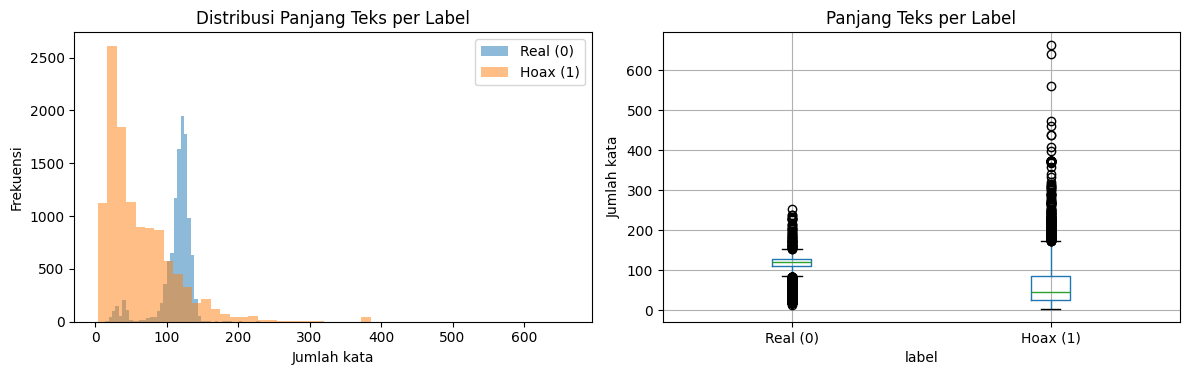

In [ ]:
df_kombinasi["n_words"] = df_kombinasi["text"].str.split().str.len()
df_kombinasi["n_chars"] = df_kombinasi["text"].str.len()

print("Statistik jumlah kata per label:")
print(
    df_kombinasi
    .groupby("label")["n_words"]
    .describe()
    .round(2)
)

print("\nStatistik jumlah karakter per label:")
print(
    df_kombinasi
    .groupby("label")["n_chars"]
    .describe()
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, name in [(0, "Real (0)"), (1, "Hoax (1)")]:
    axes[0].hist(
        df_kombinasi[df_kombinasi["label"] == label]["n_words"],
        bins=50,
        alpha=0.5,
        label=name
    )

axes[0].set_xlabel("Jumlah kata")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Panjang Teks per Label")
axes[0].legend()

df_kombinasi.boxplot(column="n_words", by="label", ax=axes[1])
axes[1].set_xticklabels(["Real (0)", "Hoax (1)"])
axes[1].set_ylabel("Jumlah kata")
axes[1].set_title("Panjang Teks per Label")

fig.suptitle("")
plt.tight_layout()
plt.show()

```
Teks berita nyata (Real) secara konsisten lebih panjang daripada teks hoax, baik dihitung dari jumlah kata maupun karakter.
Selisihnya cukup besar: rata-rata berita Real hampir 2× lebih panjang dibanding Hoax.

###Top kata per label (Real vs Hoax)
- kata apa yang sering muncul di berita Real
- kata apa yang sering muncul di berita Hoax

Top 15 kata di berita Real (label 0):
[('jakarta', 12508), ('dalam', 10752), ('antara', 6008), ('indonesia', 5666), ('tidak', 4845), ('tersebut', 4824), ('bisa', 4759), ('menjadi', 4540), ('saat', 4471), ('kompas', 4198), ('com', 4162), ('kata', 4149), ('lebih', 3803), ('tahun', 3719), ('ada', 3545)]

Top 15 kata di berita Hoax (label 1):
[('video', 7295), ('akun', 5984), ('indonesia', 4854), ('facebook', 4493), ('dalam', 3660), ('tidak', 3637), ('narasi', 3630), ('oleh', 3190), ('beredar', 2908), ('prabowo', 2554), ('tersebut', 2519), ('sebuah', 2384), ('tahun', 2353), ('cek', 2265), ('ada', 2213)]


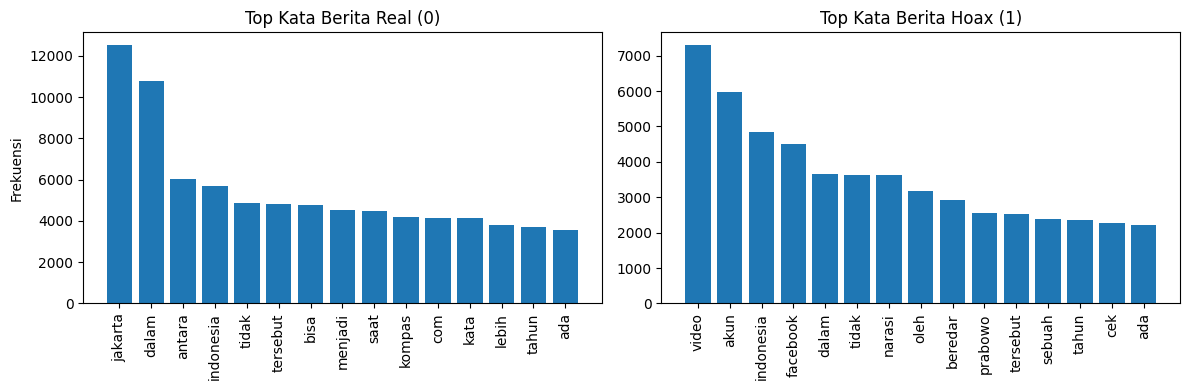

In [ ]:
stopword_sederhana = set([
    "yang","dan","di","ke","dari","untuk","pada","ini","itu",
    "dengan","akan","karena","sebagai","para","juga","atau"
])

def top_words(df, label_value, top_n=15):
    texts = df[df["label"] == label_value]["text"]
    counter = Counter()
    for t in texts:
        for w in t.split():
            if w not in stopword_sederhana and len(w) > 2:
                counter.update([w])
    return counter.most_common(top_n)

top_real = top_words(df_kombinasi, 0, 15)
top_hoax = top_words(df_kombinasi, 1, 15)

print("Top 15 kata di berita Real (label 0):")
print(top_real)

print("\nTop 15 kata di berita Hoax (label 1):")
print(top_hoax)

words_real, counts_real = zip(*top_real)
words_hoax, counts_hoax = zip(*top_hoax)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(words_real)), counts_real)
axes[0].set_xticks(range(len(words_real)))
axes[0].set_xticklabels(words_real, rotation=90)
axes[0].set_title("Top Kata Berita Real (0)")
axes[0].set_ylabel("Frekuensi")

axes[1].bar(range(len(words_hoax)), counts_hoax)
axes[1].set_xticks(range(len(words_hoax)))
axes[1].set_xticklabels(words_hoax, rotation=90)
axes[1].set_title("Top Kata Berita Hoax (1)")

plt.tight_layout()
plt.show()

###Frasa (bigram) paling sering (Real vs Hoax)
Dari semua berita Real / Hoax, frasa dua kata apa yang paling sering muncul?

Top 15 bigram di berita Real (label 0):
[('kompas com', 4097), ('jakarta antara', 3016), ('di jakarta', 2615), ('to continue', 1982), ('scroll to', 1981), ('continue with', 1981), ('with content', 1981), ('salah satu', 1349), ('jakarta kompas', 1339), ('di indonesia', 1328), ('saat ini', 1036), ('jakarta selatan', 946), ('rp triliun', 822), ('yang lebih', 730), ('dki jakarta', 674)]

Top 15 bigram di berita Hoax (label 1):
[('akun facebook', 3049), ('ini ini', 2116), ('cek fakta', 1966), ('narasi yang', 1904), ('kompas com', 1875), ('facebook ini', 1719), ('ini dan', 1697), ('oleh akun', 1663), ('media sosial', 1581), ('dan ini', 1491), ('video yang', 1472), ('di media', 1336), ('beredar di', 1124), ('yang diklaim', 1122), ('berikut narasi', 1073)]


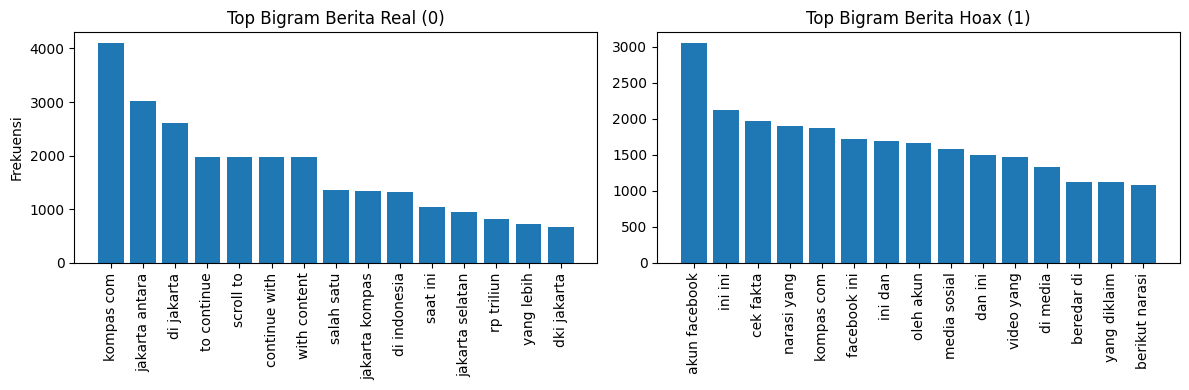

In [ ]:
def top_bigrams(df, label_value, top_n=15):
    texts = df[df["label"] == label_value]["text"]
    counter = Counter()
    for t in texts:
        words = t.split()
        bigrams = zip(words, words[1:])
        counter.update([" ".join(bg) for bg in bigrams])
    return counter.most_common(top_n)

top_bigram_real = top_bigrams(df_kombinasi, 0, 15)
top_bigram_hoax = top_bigrams(df_kombinasi, 1, 15)

print("Top 15 bigram di berita Real (label 0):")
print(top_bigram_real)

print("\nTop 15 bigram di berita Hoax (label 1):")
print(top_bigram_hoax)

phr_real, cnt_real = zip(*top_bigram_real)
phr_hoax, cnt_hoax = zip(*top_bigram_hoax)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(phr_real)), cnt_real)
axes[0].set_xticks(range(len(phr_real)))
axes[0].set_xticklabels(phr_real, rotation=90)
axes[0].set_title("Top Bigram Berita Real (0)")
axes[0].set_ylabel("Frekuensi")

axes[1].bar(range(len(phr_hoax)), cnt_hoax)
axes[1].set_xticks(range(len(phr_hoax)))
axes[1].set_xticklabels(phr_hoax, rotation=90)
axes[1].set_title("Top Bigram Berita Hoax (1)")

plt.tight_layout()
plt.show()

## Model Klasifikasi

### Train–Test Split

In [ ]:
df_model = df_kombinasi[["text", "label"]].dropna().drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

X = df_model["text"]
y = df_model["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Train: 14541
Val  : 3116
Test : 3116


### TF-IDF dan Model Baseline (Logistic Regression)

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(
    max_iter=200,
    n_jobs=-1
)

clf.fit(X_train_vec, y_train)

LogisticRegression(max_iter=200, n_jobs=-1)

### Evaluasi di Validation Set

In [ ]:
y_val_pred = clf.predict(X_val_vec)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print()
print("Classification report (Val):")
print(classification_report(y_val, y_val_pred, digits=4))

Validation accuracy: 0.9833119383825417

Classification report (Val):
              precision    recall  f1-score   support

           0     0.9839    0.9851    0.9845      1673
           1     0.9827    0.9813    0.9820      1443

    accuracy                         0.9833      3116
   macro avg     0.9833    0.9832    0.9832      3116
weighted avg     0.9833    0.9833    0.9833      3116



### Evaluasi di Test Set

Test accuracy: 0.9794608472400513

Classification report (Test):
              precision    recall  f1-score   support

           0     0.9780    0.9839    0.9809      1673
           1     0.9812    0.9744    0.9777      1443

    accuracy                         0.9795      3116
   macro avg     0.9796    0.9791    0.9793      3116
weighted avg     0.9795    0.9795    0.9795      3116



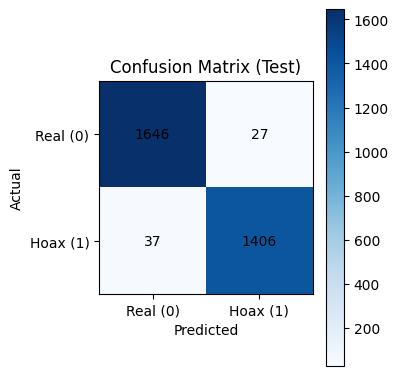

In [ ]:
y_test_pred = clf.predict(X_test_vec)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print()
print("Classification report (Test):")
print(classification_report(y_test, y_test_pred, digits=4))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.xticks([0, 1], ["Real (0)", "Hoax (1)"])
plt.yticks([0, 1], ["Real (0)", "Hoax (1)"])
plt.colorbar()
plt.tight_layout()
plt.show()

### ROC Curve dan Probabilitas Prediksi

AUC: 0.9982979439046384


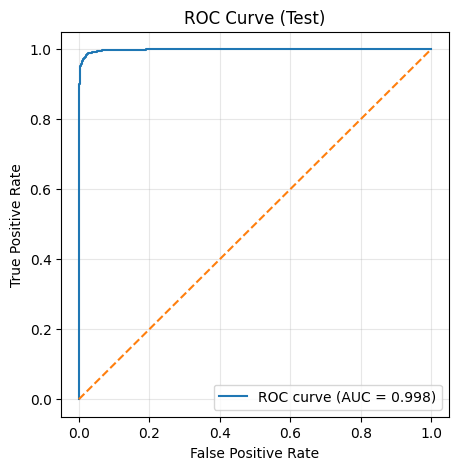

In [ ]:
y_test_proba = clf.predict_proba(X_test_vec)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
label_map = {0: "Real", 1: "Hoax"}

def predict_news(text_raw):
    text_clean = clean_text(text_raw)
    X_vec = vectorizer.transform([text_clean])
    proba = clf.predict_proba(X_vec)[0, 1]
    label = int(proba >= 0.5)
    return label_map[label], float(proba)

contoh_berita = """
Jakarta (ANTARA) - Anggota DPR menilai pemerintah perlu memperkuat literasi digital
masyarakat untuk menangkal penyebaran berita hoaks di media sosial.
"""

hasil_label, skor_hoax = predict_news(contoh_berita)
print("Prediksi:", hasil_label)
print("Probabilitas Hoax:", skor_hoax)

Prediksi: Real
Probabilitas Hoax: 0.34398773133949045


In [ ]:
y_train_pred = clf.predict(X_train_vec)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print()
print("Classification report (Train):")
print(classification_report(y_train, y_train_pred, digits=4))

Train accuracy: 0.9920913279691905

Classification report (Train):
              precision    recall  f1-score   support

           0     0.9899    0.9954    0.9927      7808
           1     0.9946    0.9883    0.9914      6733

    accuracy                         0.9921     14541
   macro avg     0.9923    0.9918    0.9920     14541
weighted avg     0.9921    0.9921    0.9921     14541



Download model (Deployment)

In [ ]:
import pickle
filename = 'model_prediksi.pkl'
pickle.dump(clf, open(filename, 'wb'))

from google.colab import files
files.download('model_prediksi.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>